#📌 Extracción

In [7]:
import pandas as pd
import requests

# URL del JSON
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Obtener datos
data = requests.get(url).json()

# Crear DataFrame
df = pd.DataFrame(data)

# Aplanar columnas anidadas
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

# Unir todo en un solo DataFrame
df_final = pd.concat([df[['customerID','Churn']], customer, phone, internet, account], axis=1)

# Ver resultado
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [8]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [9]:
df_final.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [10]:
# ================================
# LIMPIEZA Y MANEJO DE INCONSISTENCIAS
# ================================

# 1. Revisar valores nulos
print("Valores nulos por columna:")
print(df_final.isnull().sum())

print("\n")

# 2. Revisar tipos de datos
print("Tipos de datos:")
print(df_final.dtypes)

print("\n")

# 3. Convertir Charges.Total a valor numérico
df_final["Charges.Total"] = pd.to_numeric(df_final["Charges.Total"], errors="coerce")

# 4. Revisar nuevamente valores nulos
print("Valores nulos después de convertir Charges.Total:")
print(df_final.isnull().sum())

print("\n")

# 5. Eliminar filas con valores nulos
df_final = df_final.dropna()

# 6. Revisar duplicados
print("Número de filas duplicadas:")
print(df_final.duplicated().sum())

# 7. Eliminar duplicados si existen
df_final = df_final.drop_duplicates()

# 8. Verificar información final del dataset
print("\nInformación final del DataFrame:")
print(df_final.info())

# 9. Ver primeras filas para confirmar
print("\nPrimeras filas del dataset limpio:")
display(df_final.head())

Valores nulos por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


Tipos de datos:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
Pape

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [11]:
# Crear columna de cuentas diarias
df_final["Cuentas_Diarias"] = df_final["Charges.Monthly"] / 30

# Verificar que se creó correctamente
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [12]:
df_final[["Charges.Monthly", "Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [13]:
# Variables binarias
columnas_binarias = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

# Reemplazar Yes/No por 1/0
df_final[columnas_binarias] = df_final[columnas_binarias].replace({
    "Yes": 1,
    "No": 0
})

df_final.head()

/tmp/ipykernel_247/1483328061.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final[columnas_binarias] = df_final[columnas_binarias].replace({


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [15]:
df_final = df_final.rename(columns={
    "customerID": "ID_Cliente",
    "gender": "Genero",
    "SeniorCitizen": "Adulto_Mayor",
    "Partner": "Tiene_Pareja",
    "Dependents": "Dependientes",
    "tenure": "Meses_Cliente",
    "PhoneService": "Servicio_Telefono",
    "MultipleLines": "Multiples_Lineas",
    "InternetService": "Servicio_Internet",
    "Contract": "Tipo_Contrato",
    "PaymentMethod": "Metodo_Pago",
    "Charges.Monthly": "Cargo_Mensual",
    "Charges.Total": "Cargo_Total"
})

In [16]:
df_final.head()

,ID_Cliente,Churn,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Cliente,Servicio_Telefono,Multiples_Lineas,Servicio_Internet,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [17]:
df_final.dtypes

,0
ID_Cliente,object
Churn,object
Genero,object
Adulto_Mayor,int64
Tiene_Pareja,int64
Dependientes,int64
Meses_Cliente,int64
Servicio_Telefono,int64
Multiples_Lineas,object
Servicio_Internet,object


#📊 Carga y análisis

In [18]:
df_final.describe()

,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Cliente,Servicio_Telefono,PaperlessBilling,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158514
std,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004191
min,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.181667
50%,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,2.996667
max,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [19]:
df_final["Churn"].value_counts()

,count
Churn,
0,5163
1,1869
,224


In [20]:
df_final["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,71.154906
1,25.757993
,3.087100


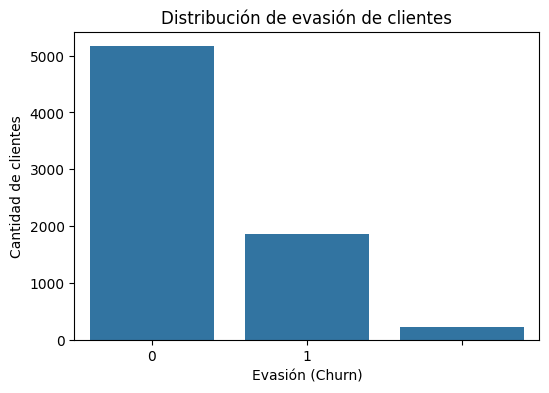

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df_final)

plt.title("Distribución de evasión de clientes")
plt.xlabel("Evasión (Churn)")
plt.ylabel("Cantidad de clientes")

plt.show()

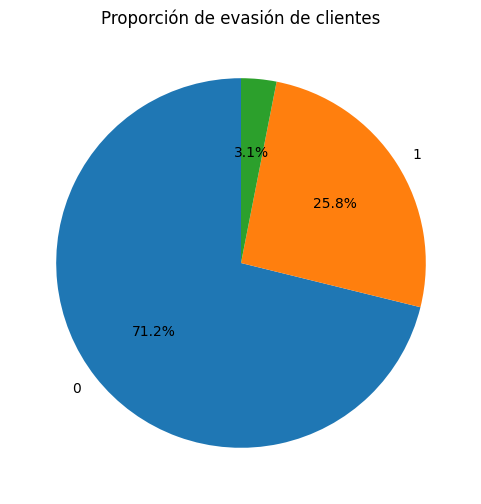

In [22]:
churn_counts = df_final["Churn"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts,
        labels=churn_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Proporción de evasión de clientes")

plt.show()

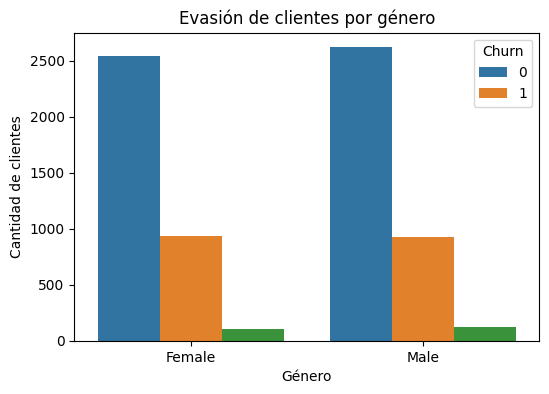

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="Genero", hue="Churn", data=df_final)

plt.title("Evasión de clientes por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de clientes")

plt.show()

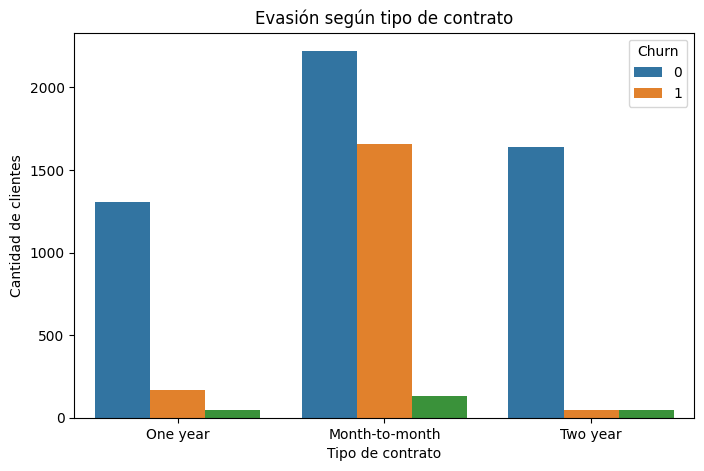

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x="Tipo_Contrato", hue="Churn", data=df_final)

plt.title("Evasión según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.show()

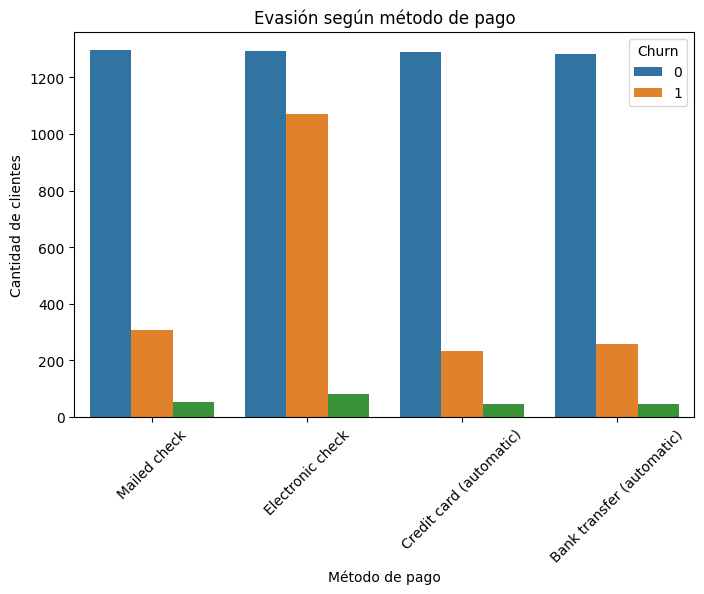

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x="Metodo_Pago", hue="Churn", data=df_final)

plt.title("Evasión según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")

plt.xticks(rotation=45)

plt.show()

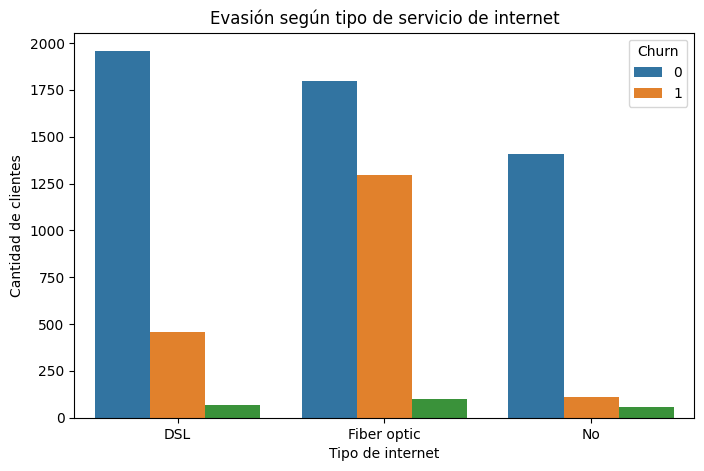

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x="Servicio_Internet", hue="Churn", data=df_final)

plt.title("Evasión según tipo de servicio de internet")
plt.xlabel("Tipo de internet")
plt.ylabel("Cantidad de clientes")

plt.show()

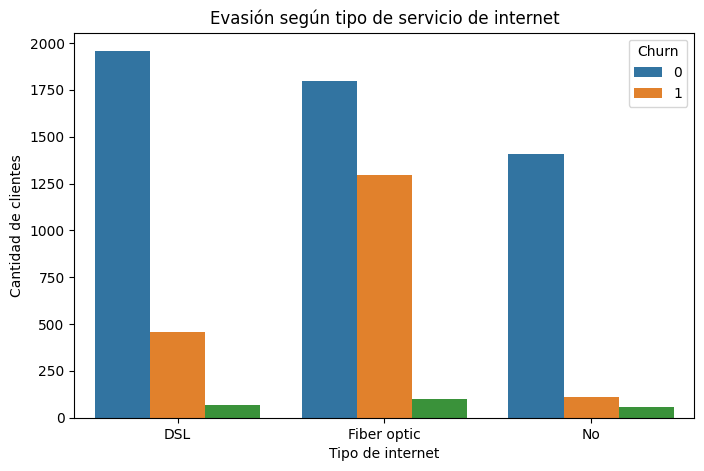

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x="Servicio_Internet", hue="Churn", data=df_final)

plt.title("Evasión según tipo de servicio de internet")
plt.xlabel("Tipo de internet")
plt.ylabel("Cantidad de clientes")

plt.show()

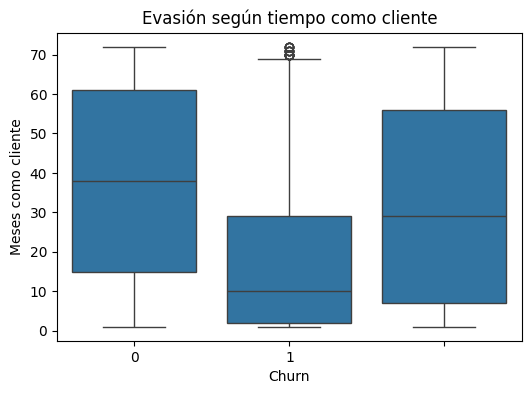

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Meses_Cliente", data=df_final)

plt.title("Evasión según tiempo como cliente")
plt.xlabel("Churn")
plt.ylabel("Meses como cliente")

plt.show()

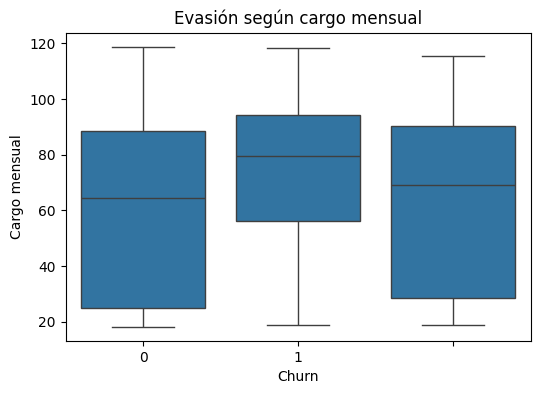

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Cargo_Mensual", data=df_final)

plt.title("Evasión según cargo mensual")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")

plt.show()

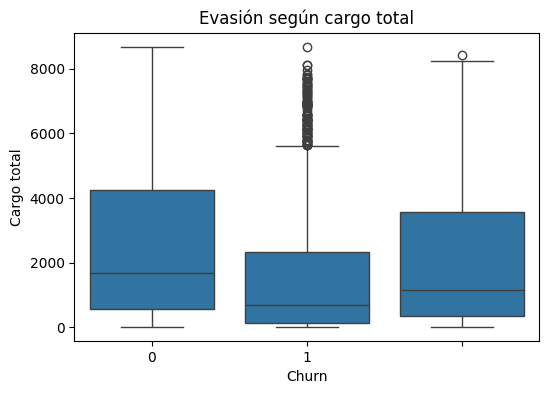

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Cargo_Total", data=df_final)

plt.title("Evasión según cargo total")
plt.xlabel("Churn")
plt.ylabel("Cargo total")

plt.show()

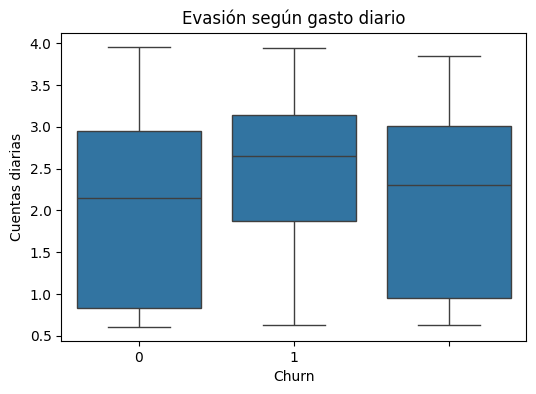

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Cuentas_Diarias", data=df_final)

plt.title("Evasión según gasto diario")
plt.xlabel("Churn")
plt.ylabel("Cuentas diarias")

plt.show()

In [32]:
# ==========================================
# ANALISIS DE EVASION (SIN GRAFICAS)
# Variables categóricas y numéricas
# ==========================================

print("=========== ANALISIS DE EVASION ===========\n")

# -------------------------------
# VARIABLES CATEGORICAS
# -------------------------------

print("ANALISIS DE VARIABLES CATEGORICAS\n")

variables_categoricas = [
    "Genero",
    "Tipo_Contrato",
    "Metodo_Pago",
    "Servicio_Internet",
    "Multiples_Lineas"
]

for var in variables_categoricas:

    print(f"\nVariable: {var}")
    print("----------------------------------")

    tabla = pd.crosstab(df_final[var], df_final["Churn"])
    porcentaje = pd.crosstab(df_final[var], df_final["Churn"], normalize="index") * 100

    print("\nConteo de clientes:")
    print(tabla)

    print("\nPorcentaje de evasión:")
    print(porcentaje.round(2))

    print("\n----------------------------------\n")


# -------------------------------
# VARIABLES NUMERICAS
# -------------------------------

print("\nANALISIS DE VARIABLES NUMERICAS\n")

variables_numericas = [
    "Meses_Cliente",
    "Cargo_Mensual",
    "Cargo_Total",
    "Cuentas_Diarias"
]

analisis_numerico = df_final.groupby("Churn")[variables_numericas].agg(["mean","median","std","min","max"])

print("Estadísticas según evasión:\n")
print(analisis_numerico)

print("\n----------------------------------\n")

# Comparación simple de promedios

for var in variables_numericas:

    promedio_churn = df_final[df_final["Churn"] == 1][var].mean()
    promedio_no_churn = df_final[df_final["Churn"] == 0][var].mean()

    print(f"Variable analizada: {var}")
    print(f"Promedio clientes que cancelaron: {round(promedio_churn,2)}")
    print(f"Promedio clientes que permanecen: {round(promedio_no_churn,2)}")

    if promedio_churn > promedio_no_churn:
        print("Insight: Los clientes que cancelan tienen valores más altos en esta variable.")
    else:
        print("Insight: Los clientes que cancelan tienen valores más bajos en esta variable.")

    print("\n----------------------------------\n")

=========== ANALISIS DE EVASION ===========

ANALISIS DE VARIABLES CATEGORICAS


Variable: Genero
----------------------------------

Conteo de clientes:
Churn      0    1     
Genero                
Female  2544  939  104
Male    2619  930  120

Porcentaje de evasión:
Churn       0      1      
Genero                    
Female  70.92  26.18  2.90
Male    71.38  25.35  3.27

----------------------------------


Variable: Tipo_Contrato
----------------------------------

Conteo de clientes:
Churn              0     1     
Tipo_Contrato                  
Month-to-month  2220  1655  130
One year        1306   166   46
Two year        1637    48   48

Porcentaje de evasión:
Churn               0      1      
Tipo_Contrato                     
Month-to-month  55.43  41.32  3.25
One year        86.03  10.94  3.03
Two year        94.46   2.77  2.77

----------------------------------


Variable: Metodo_Pago
----------------------------------

Conteo de clientes:
Churn                        

#📄Informe final

Informe de Análisis de Evasión de Clientes (Churn)
Introducción

La evasión de clientes, también conocida como Churn, es un indicador clave para las empresas de servicios, ya que representa la cantidad de clientes que deciden cancelar o abandonar un servicio en un periodo determinado. Comprender los factores que influyen en la cancelación permite a las empresas diseñar estrategias para mejorar la retención y aumentar la satisfacción de los clientes.

El objetivo de este análisis es explorar y comprender los patrones relacionados con la evasión de clientes utilizando un conjunto de datos de una empresa de telecomunicaciones. A través de técnicas de limpieza de datos, transformación de variables y análisis exploratorio, se busca identificar las características que diferencian a los clientes que permanecen en el servicio de aquellos que lo cancelan.

Este análisis permitirá identificar posibles factores de riesgo asociados con la evasión, proporcionando información valiosa para la toma de decisiones estratégicas orientadas a mejorar la retención de clientes.

Limpieza y Tratamiento de Datos

El primer paso del análisis consistió en la extracción de los datos desde una API en formato JSON, los cuales fueron cargados en un DataFrame utilizando la biblioteca Pandas.

Posteriormente, se realizó una exploración inicial del conjunto de datos para comprender su estructura, tipos de variables y detectar posibles inconsistencias. Durante esta etapa se revisaron los tipos de datos, la presencia de valores nulos y la existencia de registros duplicados.

Entre las principales acciones realizadas se encuentran:

Conversión de la columna Charges.Total a formato numérico, ya que originalmente estaba almacenada como texto.

Identificación y tratamiento de valores nulos generados durante la conversión de datos.

Verificación de registros duplicados en el conjunto de datos.

Creación de una nueva variable llamada Cuentas_Diarias, calculada a partir del cargo mensual dividido entre 30, con el objetivo de analizar el gasto diario de los clientes.

Además, se realizó un proceso de estandarización y transformación de variables, que incluyó:

Conversión de variables categóricas binarias como "Yes" y "No" a valores numéricos (1 y 0).

Traducción y renombramiento de algunas columnas para facilitar la interpretación del análisis.

Organización del dataset para mejorar la claridad y consistencia de los datos.

Después de estos procesos, se obtuvo un conjunto de datos limpio y estructurado, listo para realizar el análisis exploratorio.

Análisis Exploratorio de Datos

El análisis exploratorio se centró en examinar la relación entre diferentes variables del dataset y la evasión de clientes.

Distribución de la evasión

Se analizó la proporción de clientes que permanecen en el servicio frente a aquellos que cancelaron. Este análisis permite comprender la magnitud del problema de evasión dentro del conjunto de datos.

Análisis de variables categóricas

Se exploró cómo se distribuye la evasión según diferentes variables categóricas, entre ellas:

Género

Tipo de contrato

Método de pago

Tipo de servicio de internet

Uso de múltiples líneas telefónicas

El análisis mostró que el tipo de contrato es uno de los factores más relevantes. Los clientes con contratos mes a mes (Month-to-month) presentan una tasa de evasión considerablemente mayor en comparación con aquellos que cuentan con contratos de uno o dos años.

También se identificó que los clientes que utilizan Electronic Check como método de pago tienen una mayor proporción de cancelaciones en comparación con otros métodos de pago automáticos.

En cuanto al servicio de internet, los clientes con fibra óptica presentan niveles de evasión más altos que aquellos con DSL o que no cuentan con servicio de internet.

Por otro lado, el género no mostró diferencias significativas en la tasa de cancelación.

Análisis de variables numéricas

También se analizaron variables numéricas importantes como:

Meses de permanencia del cliente

Cargo mensual

Cargo total

Cuentas diarias

El análisis mostró que los clientes que cancelan el servicio tienen en promedio menos tiempo con la empresa, lo que indica que la evasión ocurre principalmente durante los primeros meses de relación con el cliente.

Además, los clientes que cancelan presentan cargos mensuales y costos diarios más altos, lo que sugiere que el precio del servicio podría influir en la decisión de abandonar la empresa.

Por otro lado, el cargo total acumulado es menor en los clientes que cancelan, lo cual es consistente con el hecho de que permanecen menos tiempo como clientes.

Conclusiones e Insights

A partir del análisis realizado, se identificaron varios factores asociados con la evasión de clientes.

Uno de los hallazgos más relevantes es que la duración del contrato tiene una fuerte relación con la permanencia del cliente. Los clientes con contratos de mayor duración muestran niveles de cancelación significativamente más bajos.

También se observó que los clientes con mayor cargo mensual presentan mayor probabilidad de cancelar el servicio, lo que indica que el precio puede ser un factor importante en la decisión del cliente.

Otro insight importante es que los clientes más nuevos son los que presentan mayor riesgo de evasión, lo que sugiere que los primeros meses de servicio son críticos para la retención.

Además, se identificó que el método de pago Electronic Check está asociado con mayores tasas de cancelación, lo que podría indicar menor compromiso o menor automatización en los pagos.

Finalmente, el análisis del tipo de servicio de internet sugiere que los clientes con fibra óptica presentan mayores tasas de evasión, lo cual podría estar relacionado con expectativas del servicio o costos más elevados.

Recomendaciones

Con base en los hallazgos obtenidos, se proponen algunas estrategias que podrían ayudar a reducir la evasión de clientes.

Una primera recomendación es incentivar contratos de mayor duración, ofreciendo beneficios o descuentos a los clientes que opten por contratos de uno o dos años.

También sería recomendable analizar la estructura de precios de los planes, especialmente aquellos con cargos mensuales más elevados, para asegurar que el cliente perciba un valor adecuado por el servicio.

Otra estrategia importante sería implementar programas de retención para clientes nuevos, ya que los primeros meses de servicio parecen ser el periodo con mayor riesgo de cancelación.

Asimismo, promover métodos de pago automáticos podría ayudar a reducir la evasión, ya que los clientes que utilizan estos métodos presentan menores tasas de cancelación.

Finalmente, se recomienda realizar un análisis más profundo del servicio de fibra óptica, con el fin de identificar posibles áreas de mejora relacionadas con calidad del servicio, precio o experiencia del cliente.